<a href="https://colab.research.google.com/github/KSG-SUKUNA/COMPUTER-VISION-AND-PATTERN-RECOGNITION-CVPR-/blob/main/CNN_22_49218_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Import Libraries

The required libraries are imported in one place, following the clean section-by-section structure of the faculty examples.

In [1]:
# ==============================================================================
# CELL PURPOSE: Install the additional package used to print the detailed CNN architecture summary.
# ASSIGNMENT REQUIREMENT: Model Architecture: documented architecture with a detailed summary.
# NOTE: Run the notebook cells in order so variables and outputs remain available.
# ==============================================================================
# Install only the small package required for the detailed model summary.
!pip -q install torchinfo

In [2]:
# ==============================================================================
# CELL PURPOSE: Import all libraries required for data handling, CNN development, training, evaluation, and visualization.
# ASSIGNMENT REQUIREMENT: Code Quality and Documentation: organized imports and readable implementation.
# NOTE: Run the notebook cells in order so variables and outputs remain available.
# ==============================================================================
import os
import random
import time
import json
import copy
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms
from torchinfo import summary

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

warnings.filterwarnings('ignore')
print('PyTorch version:', torch.__version__)

PyTorch version: 2.11.0+cu128


## 2. Configuration and Hyperparameters

The hyperparameters are kept together, similar to the faculty CNN example. This makes the experiment easy to understand and reproduce.



In [3]:
# ==============================================================================
# CELL PURPOSE: Set student information, hyperparameters, output paths, random seeds, and the available computation device.
# ASSIGNMENT REQUIREMENT: Training and Optimization: state hyperparameters and provide a rationale in the surrounding markdown.
# NOTE: Run the notebook cells in order so variables and outputs remain available.
# ==============================================================================
# =========================
# Experiment Configuration
# =========================
STUDENT_ID = '22-49218-3'
STUDENT_NAME = 'Rahman, A.K.M Tamim'

random_seed = 42
image_size = 64
batch_size = 256
epochs = 30
learning_rate = 0.001
minimum_learning_rate = 0.00001
weight_decay = 0.0001
num_workers = 2

train_ratio = 0.70
validation_ratio = 0.15
test_ratio = 0.15

DATA_ROOT = Path('/content/eurosat_data')
OUTPUT_ROOT = Path('/content/cnn_assignment_outputs')
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

BEST_MODEL_PATH = OUTPUT_ROOT / f'CNN_{STUDENT_ID}_best.pth'
FINAL_MODEL_PATH = OUTPUT_ROOT / f'CNN_{STUDENT_ID}_final.pth'
FULL_MODEL_PATH = OUTPUT_ROOT / f'CNN_{STUDENT_ID}_full_model.pth'
HISTORY_PATH = OUTPUT_ROOT / f'CNN_{STUDENT_ID}_history.csv'
REPORT_PATH = OUTPUT_ROOT / f'CNN_{STUDENT_ID}_classification_report.csv'

# Reproducibility
random.seed(random_seed)
np.random.seed(random_seed)
torch.manual_seed(random_seed)
torch.cuda.manual_seed_all(random_seed)

# GPU selection, following the faculty example style.
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))

Device: cuda
GPU: NVIDIA A100-SXM4-80GB


## 3. Load and Explore the Dataset

### Selected Dataset: EuroSAT RGB

EuroSAT is an open-access multiclass image dataset based on Sentinel-2 satellite images. It contains **27,000 RGB images** distributed across **10 land-use and land-cover classes**.

The dataset is downloaded automatically through `torchvision`, so no Kaggle API key is required in Colab.

In [4]:
# ==============================================================================
# CELL PURPOSE: Download and load the selected open-access multiclass image dataset.
# ASSIGNMENT REQUIREMENT: Data Loading and Preprocessing: load the dataset.
# NOTE: Run the notebook cells in order so variables and outputs remain available.
# ==============================================================================
# Download the complete dataset without applying a transform yet.
base_dataset = datasets.EuroSAT(
    root=str(DATA_ROOT),
    download=True,
    transform=None
)

class_names = base_dataset.classes
num_classes = len(class_names)
targets = np.array(base_dataset.targets)
indices = np.arange(len(base_dataset))

print('Dataset name: EuroSAT RGB')
print('Total images:', len(base_dataset))
print('Number of classes:', num_classes)
print('Class names:', class_names)

100%|██████████| 94.3M/94.3M [00:01<00:00, 79.4MB/s]


Dataset name: EuroSAT RGB
Total images: 27000
Number of classes: 10
Class names: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


,Class Index,Class Name,Number of Images
0,0,AnnualCrop,3000
1,1,Forest,3000
2,2,HerbaceousVegetation,3000
3,3,Highway,2500
4,4,Industrial,2500
5,5,Pasture,2000
6,6,PermanentCrop,2500
7,7,Residential,3000
8,8,River,2500
9,9,SeaLake,3000


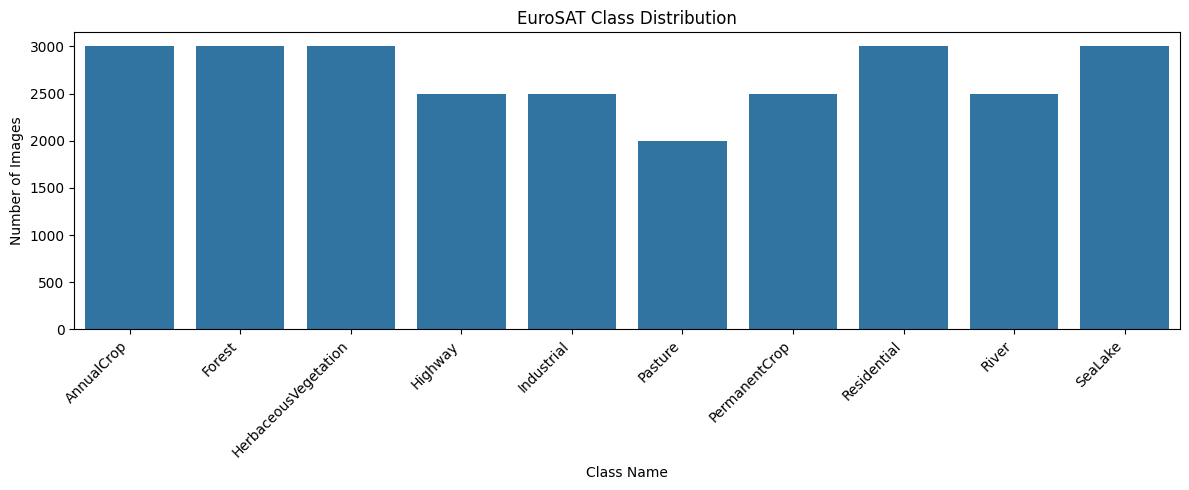

In [5]:
# ==============================================================================
# CELL PURPOSE: Inspect the number of samples in every class to understand class balance.
# ASSIGNMENT REQUIREMENT: Data Handling: explore the loaded dataset before training.
# NOTE: Run the notebook cells in order so variables and outputs remain available.
# ==============================================================================
# Display class distribution.
class_counts = pd.Series(targets).value_counts().sort_index()
class_distribution = pd.DataFrame({
    'Class Index': range(num_classes),
    'Class Name': class_names,
    'Number of Images': class_counts.values
})

display(class_distribution)

plt.figure(figsize=(12, 5))
sns.barplot(data=class_distribution, x='Class Name', y='Number of Images')
plt.title('EuroSAT Class Distribution')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

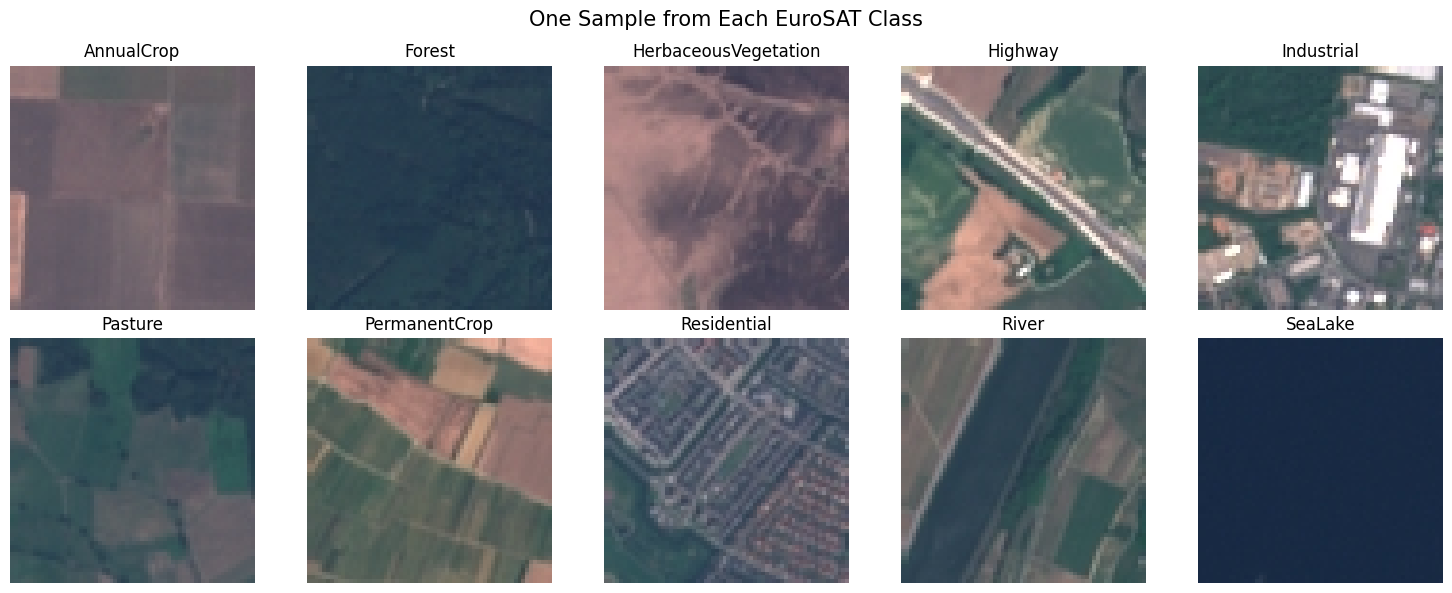

In [6]:
# ==============================================================================
# CELL PURPOSE: Visualize one representative image from each class and verify the class labels.
# ASSIGNMENT REQUIREMENT: Data Handling and Documentation: visually explore the dataset.
# NOTE: Run the notebook cells in order so variables and outputs remain available.
# ==============================================================================
# Show one sample image from each class.
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for class_index, axis in enumerate(axes.flatten()):
    sample_index = np.where(targets == class_index)[0][0]
    image, label = base_dataset[sample_index]
    axis.imshow(image)
    axis.set_title(class_names[label])
    axis.axis('off')
plt.suptitle('One Sample from Each EuroSAT Class', fontsize=15)
plt.tight_layout()
plt.show()

## 4. Data Preprocessing, Augmentation, and Splitting

The data is split using **stratified sampling**, which preserves the class proportions in training, validation, and test subsets.

Training augmentation includes random horizontal and vertical flips, small rotations, and color jitter. Validation and test images use only deterministic preprocessing.

In [7]:
# ==============================================================================
# CELL PURPOSE: Define training augmentation and deterministic validation/test preprocessing.
# ASSIGNMENT REQUIREMENT: Data Loading and Preprocessing: preprocess images and apply regularization through augmentation.
# NOTE: Run the notebook cells in order so variables and outputs remain available.
# ==============================================================================
# ImageNet normalization values are widely used for RGB image inputs.
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.10),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

validation_test_transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

In [8]:
# ==============================================================================
# CELL PURPOSE: Create stratified training, validation, and test indices while preserving class proportions.
# ASSIGNMENT REQUIREMENT: Data Handling: create separate training, validation, and test partitions.
# NOTE: Run the notebook cells in order so variables and outputs remain available.
# ==============================================================================
# First split: training set and temporary set.
train_indices, temporary_indices = train_test_split(
    indices,
    test_size=(validation_ratio + test_ratio),
    stratify=targets,
    random_state=random_seed
)

# Second split: validation and test sets.
temporary_targets = targets[temporary_indices]
validation_indices, test_indices = train_test_split(
    temporary_indices,
    test_size=test_ratio / (validation_ratio + test_ratio),
    stratify=temporary_targets,
    random_state=random_seed
)

print('Training images:', len(train_indices))
print('Validation images:', len(validation_indices))
print('Test images:', len(test_indices))
print('Total:', len(train_indices) + len(validation_indices) + len(test_indices))

Training images: 18900
Validation images: 4050
Test images: 4050
Total: 27000


In [9]:
# ==============================================================================
# CELL PURPOSE: Define training augmentation and deterministic validation/test preprocessing.
# ASSIGNMENT REQUIREMENT: Data Loading and Preprocessing: preprocess images and apply regularization through augmentation.
# NOTE: Run the notebook cells in order so variables and outputs remain available.
# ==============================================================================
class DatasetSubset(Dataset):
    """Apply a separate transform to a selected subset of a base dataset."""

    def __init__(self, dataset, selected_indices, transform=None):
        self.dataset = dataset
        self.selected_indices = list(selected_indices)
        self.transform = transform

    def __len__(self):
        return len(self.selected_indices)

    def __getitem__(self, item):
        original_index = self.selected_indices[item]
        image, label = self.dataset[original_index]
        if self.transform is not None:
            image = self.transform(image)
        return image, label


train_dataset = DatasetSubset(base_dataset, train_indices, train_transform)
validation_dataset = DatasetSubset(
    base_dataset, validation_indices, validation_test_transform
)
test_dataset = DatasetSubset(base_dataset, test_indices, validation_test_transform)

### Create Training, Validation, and Test Data Loaders

The assignment explicitly requires training and validation data loaders with batch size. A separate test loader is also created for final evaluation.

In [10]:
# ==============================================================================
# CELL PURPOSE: Create the training, validation, and test DataLoaders with the configured batch size.
# ASSIGNMENT REQUIREMENT: Data Loading and Preprocessing: create training and validation data loaders with batch size.
# NOTE: Run the notebook cells in order so variables and outputs remain available.
# ==============================================================================
loader_generator = torch.Generator()
loader_generator.manual_seed(random_seed)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=torch.cuda.is_available(),
    generator=loader_generator
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=torch.cuda.is_available()
)

print('Training batches:', len(train_loader))
print('Validation batches:', len(validation_loader))
print('Test batches:', len(test_loader))

Training batches: 74
Validation batches: 16
Test batches: 16


In [11]:
# ==============================================================================
# CELL PURPOSE: Check one batch to confirm tensor dimensions, labels, and normalized value ranges.
# ASSIGNMENT REQUIREMENT: Data Handling: verify that preprocessing and batching work as expected.
# NOTE: Run the notebook cells in order so variables and outputs remain available.
# ==============================================================================
# Verify one batch.
images, labels = next(iter(train_loader))
print('Image batch shape:', images.shape)
print('Label batch shape:', labels.shape)
print('Minimum pixel value after normalization:', images.min().item())
print('Maximum pixel value after normalization:', images.max().item())

Image batch shape: torch.Size([256, 3, 64, 64])
Label batch shape: torch.Size([256])
Minimum pixel value after normalization: -2.1179039478302
Maximum pixel value after normalization: 2.640000104904175


## 5. Define the Custom CNN Architecture

The model is built from scratch rather than using a pretrained architecture. The design uses repeated convolution, batch normalization, ReLU, and max-pooling blocks. The number of channels increases from 32 to 256 while the spatial resolution decreases.

### Architecture Flow

`Input → Conv Block 1 → Conv Block 2 → Conv Block 3 → Conv Block 4 → Adaptive Average Pooling → Fully Connected Layer → 10 Class Scores`

### Design Justification

* `3 × 3` convolutions capture local visual patterns.
* Batch normalization makes training more stable.
* ReLU introduces nonlinearity.
* Max pooling reduces spatial dimensions and computation.
* Dropout reduces overfitting.
* Adaptive average pooling keeps the classifier compact and reduces parameters.

In [12]:
# ==============================================================================
# CELL PURPOSE: Define the custom convolutional neural network from scratch.
# ASSIGNMENT REQUIREMENT: Model Architecture: build a custom CNN with convolution, pooling, batch normalization, dropout, and classification layers.
# NOTE: Run the notebook cells in order so variables and outputs remain available.
# ==============================================================================
class CNNModel(nn.Module):
    def __init__(self, number_of_classes=10):
        super(CNNModel, self).__init__()

        self.feature_extractor = nn.Sequential(
            # Block 1: 3 x 64 x 64 -> 32 x 32 x 32
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Block 2: 32 x 32 x 32 -> 64 x 16 x 16
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Block 3: 64 x 16 x 16 -> 128 x 8 x 8
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Block 4: 128 x 8 x 8 -> 256 x 4 x 4
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(p=0.30),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.30),
            nn.Linear(128, number_of_classes)
        )

    def forward(self, x):
        x = self.feature_extractor(x)
        x = self.global_pool(x)
        x = self.classifier(x)
        return x

In [13]:
# ==============================================================================
# CELL PURPOSE: Instantiate the custom CNN on the selected device and display its layer structure.
# ASSIGNMENT REQUIREMENT: Model Architecture: show the implemented network structure.
# NOTE: Run the notebook cells in order so variables and outputs remain available.
# ==============================================================================
# Get the model, following the order used in the faculty CNN example.
model = CNNModel(number_of_classes=num_classes).to(device)
print(model)

CNNModel(
  (feature_extractor): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU(inplace=True)
    (10): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU(inplace=True)
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): Conv2d

### Detailed Architecture Summary

The summary documents output shapes and parameter counts, satisfying the assignment requirement for a detailed model architecture.

In [14]:
# ==============================================================================
# CELL PURPOSE: Generate a detailed layer-by-layer architecture summary with output shapes and parameter counts.
# ASSIGNMENT REQUIREMENT: Model Architecture: document the architecture with a detailed summary.
# NOTE: Run the notebook cells in order so variables and outputs remain available.
# ==============================================================================
model_summary = summary(
    model,
    input_size=(1, 3, image_size, image_size),
    col_names=['input_size', 'output_size', 'num_params', 'trainable'],
    depth=4
)
print(model_summary)

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Trainable
CNNModel                                 [1, 3, 64, 64]            [1, 10]                   --                        True
├─Sequential: 1-1                        [1, 3, 64, 64]            [1, 256, 4, 4]            --                        True
│    └─Conv2d: 2-1                       [1, 3, 64, 64]            [1, 32, 64, 64]           896                       True
│    └─BatchNorm2d: 2-2                  [1, 32, 64, 64]           [1, 32, 64, 64]           64                        True
│    └─ReLU: 2-3                         [1, 32, 64, 64]           [1, 32, 64, 64]           --                        --
│    └─Conv2d: 2-4                       [1, 32, 64, 64]           [1, 32, 64, 64]           9,248                     True
│    └─BatchNorm2d: 2-5                  [1, 32, 64, 64]           [1, 32, 64, 64]           64                        True
│    

## 6. Training Setup

This section follows the sequence visible in the faculty CNN reference:

1. Get the model
2. Define optimizer
3. Define learning-rate scheduler
4. Define loss function

`Adam` is used as the optimizer, `CosineAnnealingLR` gradually reduces the learning rate, and cross-entropy loss is used for multiclass classification.

In [15]:
# ==============================================================================
# CELL PURPOSE: Prepare the model, Adam optimizer, cosine learning-rate scheduler, and cross-entropy loss.
# ASSIGNMENT REQUIREMENT: Training and Optimization: use an appropriate optimizer and cross-entropy loss for multiclass classification.
# NOTE: Run the notebook cells in order so variables and outputs remain available.
# ==============================================================================
# 1. Get the Model
model = CNNModel(number_of_classes=num_classes).to(device)

# 2. Define optimizer
optimizer = Adam(
    model.parameters(),
    lr=learning_rate,
    weight_decay=weight_decay
)

# 3. Define LR scheduler
scheduler = CosineAnnealingLR(
    optimizer,
    T_max=epochs,
    eta_min=minimum_learning_rate
)

# 4. Define loss function
criterion = nn.CrossEntropyLoss()

print('Optimizer:', optimizer.__class__.__name__)
print('Loss function:', criterion.__class__.__name__)
print('Scheduler:', scheduler.__class__.__name__)

Optimizer: Adam
Loss function: CrossEntropyLoss
Scheduler: CosineAnnealingLR


## 7. Training Loop with Validation

Separate functions are used for one training epoch and one validation epoch. The model checkpoint is saved whenever validation accuracy improves.

In [16]:
# ==============================================================================
# CELL PURPOSE: Define separate functions for one training epoch and one validation epoch.
# ASSIGNMENT REQUIREMENT: Training and Optimization: implement a clear training and validation workflow.
# NOTE: Run the notebook cells in order so variables and outputs remain available.
# ==============================================================================
def train_one_epoch(model, data_loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    for images, labels in data_loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        predictions = outputs.argmax(dim=1)
        correct_predictions += (predictions == labels).sum().item()
        total_samples += labels.size(0)

    epoch_loss = running_loss / total_samples
    epoch_accuracy = correct_predictions / total_samples
    return epoch_loss, epoch_accuracy


def validate_one_epoch(model, data_loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            predictions = outputs.argmax(dim=1)
            correct_predictions += (predictions == labels).sum().item()
            total_samples += labels.size(0)

    epoch_loss = running_loss / total_samples
    epoch_accuracy = correct_predictions / total_samples
    return epoch_loss, epoch_accuracy

In [17]:
# ==============================================================================
# CELL PURPOSE: Set student information, hyperparameters, output paths, random seeds, and the available computation device.
# ASSIGNMENT REQUIREMENT: Training and Optimization: state hyperparameters and provide a rationale in the surrounding markdown.
# NOTE: Run the notebook cells in order so variables and outputs remain available.
# ==============================================================================
# History lists for the required loss and accuracy plots.
train_loss_history = []
validation_loss_history = []
train_accuracy_history = []
validation_accuracy_history = []
learning_rate_history = []

best_validation_accuracy = 0.0
best_epoch = 0
training_start_time = time.time()

for epoch in range(epochs):
    epoch_start_time = time.time()

    train_loss, train_accuracy = train_one_epoch(
        model, train_loader, criterion, optimizer, device
    )

    validation_loss, validation_accuracy = validate_one_epoch(
        model, validation_loader, criterion, device
    )

    current_learning_rate = optimizer.param_groups[0]['lr']

    train_loss_history.append(train_loss)
    validation_loss_history.append(validation_loss)
    train_accuracy_history.append(train_accuracy)
    validation_accuracy_history.append(validation_accuracy)
    learning_rate_history.append(current_learning_rate)

    # Save the best model checkpoint.
    if validation_accuracy > best_validation_accuracy:
        best_validation_accuracy = validation_accuracy
        best_epoch = epoch + 1

        checkpoint = {
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'validation_accuracy': validation_accuracy,
            'class_names': class_names,
            'image_size': image_size,
            'student_id': STUDENT_ID
        }
        torch.save(checkpoint, BEST_MODEL_PATH)
        checkpoint_message = 'Best model saved'
    else:
        checkpoint_message = ''

    scheduler.step()

    epoch_time = time.time() - epoch_start_time
    print(f'Epoch [{epoch + 1:02d}/{epochs:02d}]')
    print(f'  Train Loss: {train_loss:.4f} | Train Accuracy: {train_accuracy * 100:.2f}%')
    print(f'  Validation Loss: {validation_loss:.4f} | Validation Accuracy: {validation_accuracy * 100:.2f}%')
    print(f'  Learning Rate: {current_learning_rate:.8f} | Time: {epoch_time:.1f} sec {checkpoint_message}')
    print('-' * 90)

training_time_minutes = (time.time() - training_start_time) / 60
print(f'Training completed in {training_time_minutes:.2f} minutes.')
print(f'Best validation accuracy: {best_validation_accuracy * 100:.2f}% at epoch {best_epoch}')

Epoch [01/30]
  Train Loss: 1.0819 | Train Accuracy: 62.70%
  Validation Loss: 0.7462 | Validation Accuracy: 72.37%
  Learning Rate: 0.00100000 | Time: 12.7 sec Best model saved
------------------------------------------------------------------------------------------
Epoch [02/30]
  Train Loss: 0.7132 | Train Accuracy: 75.11%
  Validation Loss: 0.7311 | Validation Accuracy: 75.26%
  Learning Rate: 0.00099729 | Time: 12.6 sec Best model saved
------------------------------------------------------------------------------------------
Epoch [03/30]
  Train Loss: 0.6006 | Train Accuracy: 79.62%
  Validation Loss: 0.6284 | Validation Accuracy: 79.33%
  Learning Rate: 0.00098918 | Time: 12.3 sec Best model saved
------------------------------------------------------------------------------------------
Epoch [04/30]
  Train Loss: 0.5232 | Train Accuracy: 82.15%
  Validation Loss: 0.4842 | Validation Accuracy: 84.44%
  Learning Rate: 0.00097577 | Time: 12.4 sec Best model saved
---------------

## 8. Plot Training and Validation Loss/Accuracy Curves

These visualizations are explicitly required in the assignment rubric.

In [18]:
# ==============================================================================
# CELL PURPOSE: Store epoch-by-epoch loss, accuracy, and learning-rate history in a table and CSV file.
# ASSIGNMENT REQUIREMENT: Visualizations and Documentation: preserve the values used for the required curves.
# NOTE: Run the notebook cells in order so variables and outputs remain available.
# ==============================================================================
history_dataframe = pd.DataFrame({
    'Epoch': np.arange(1, epochs + 1),
    'Training Loss': train_loss_history,
    'Validation Loss': validation_loss_history,
    'Training Accuracy': train_accuracy_history,
    'Validation Accuracy': validation_accuracy_history,
    'Learning Rate': learning_rate_history
})

history_dataframe.to_csv(HISTORY_PATH, index=False)
display(history_dataframe.tail())

,Epoch,Training Loss,Validation Loss,Training Accuracy,Validation Accuracy,Learning Rate
25,26,0.105373,0.095240,0.965503,0.965432,0.000076
26,27,0.101716,0.092206,0.965767,0.969630,0.000053
27,28,0.091810,0.089009,0.969365,0.967901,0.000034
28,29,0.096661,0.092496,0.967619,0.968395,0.000021
29,30,0.092934,0.089965,0.969418,0.969630,0.000013


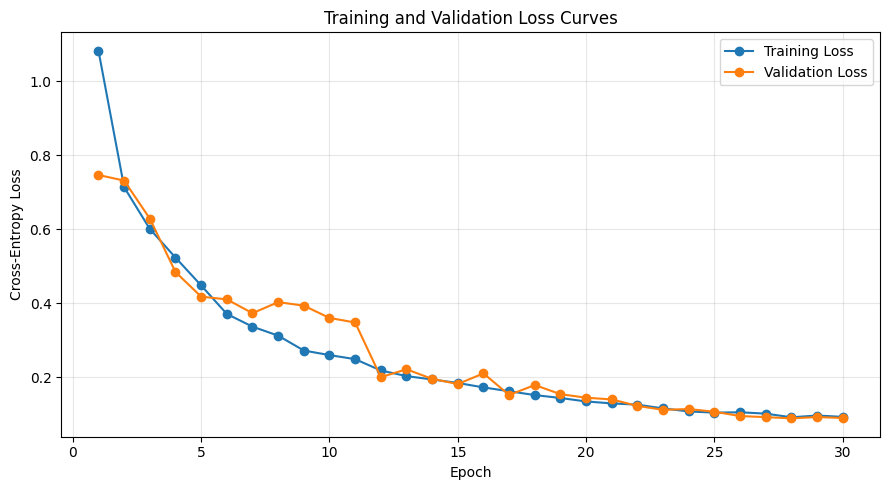

In [19]:
# ==============================================================================
# CELL PURPOSE: Plot and save the training and validation loss curves.
# ASSIGNMENT REQUIREMENT: Visualizations: plot training and validation loss curves.
# NOTE: Run the notebook cells in order so variables and outputs remain available.
# ==============================================================================
plt.figure(figsize=(9, 5))
plt.plot(history_dataframe['Epoch'], history_dataframe['Training Loss'], marker='o', label='Training Loss')
plt.plot(history_dataframe['Epoch'], history_dataframe['Validation Loss'], marker='o', label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Cross-Entropy Loss')
plt.title('Training and Validation Loss Curves')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_ROOT / 'loss_curves.png', dpi=200, bbox_inches='tight')
plt.show()

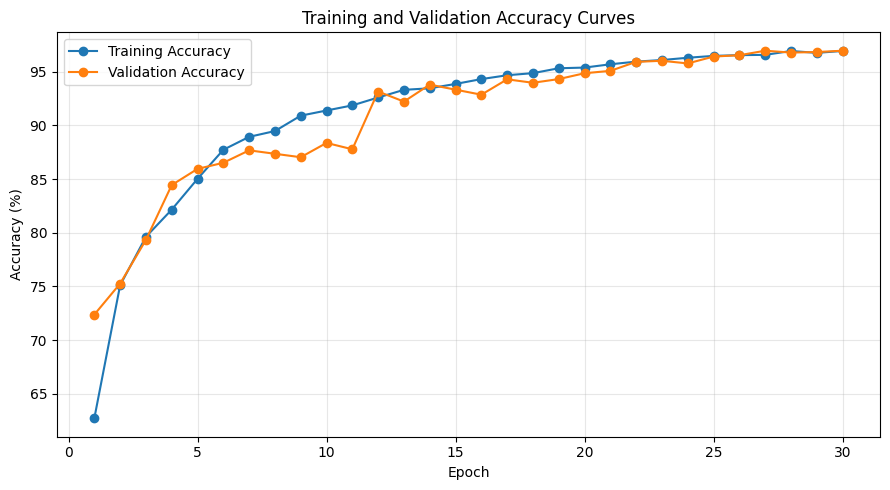

In [20]:
# ==============================================================================
# CELL PURPOSE: Plot and save the training and validation accuracy curves.
# ASSIGNMENT REQUIREMENT: Visualizations: plot training and validation accuracy curves.
# NOTE: Run the notebook cells in order so variables and outputs remain available.
# ==============================================================================
plt.figure(figsize=(9, 5))
plt.plot(history_dataframe['Epoch'], history_dataframe['Training Accuracy'] * 100, marker='o', label='Training Accuracy')
plt.plot(history_dataframe['Epoch'], history_dataframe['Validation Accuracy'] * 100, marker='o', label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Training and Validation Accuracy Curves')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_ROOT / 'accuracy_curves.png', dpi=200, bbox_inches='tight')
plt.show()

## 9. Save and Load the Trained Model

This section closely follows the purpose of the faculty-provided model save/load example. Both a checkpoint dictionary and a final state dictionary are saved.

In [21]:
# ==============================================================================
# CELL PURPOSE: Save the final trained model weights as a .pth file and report all saved file sizes.
# ASSIGNMENT REQUIREMENT: Code Quality, Documentation, and Saved Model: save trained model weights.
# NOTE: Run the notebook cells in order so variables and outputs remain available.
# ==============================================================================
# Save the final model state dictionary.
torch.save(model.state_dict(), FINAL_MODEL_PATH)

print('Best checkpoint saved at:', BEST_MODEL_PATH)
print('Final model weights saved at:', FINAL_MODEL_PATH)
print('Best checkpoint size: {:.2f} MB'.format(BEST_MODEL_PATH.stat().st_size / (1024 ** 2)))
print('Final weights size: {:.2f} MB'.format(FINAL_MODEL_PATH.stat().st_size / (1024 ** 2)))

Best checkpoint saved at: /content/cnn_assignment_outputs/CNN_22-49218-3_best.pth
Final model weights saved at: /content/cnn_assignment_outputs/CNN_22-49218-3_final.pth
Best checkpoint size: 7.12 MB
Final weights size: 2.38 MB


In [22]:
# ==============================================================================
# CELL PURPOSE: Load the best saved checkpoint into a fresh CNN instance and verify the recorded training information.
# ASSIGNMENT REQUIREMENT: Saved Model: demonstrate the faculty-reference save and load workflow.
# NOTE: Run the notebook cells in order so variables and outputs remain available.
# ==============================================================================
def load_model_checkpoint(checkpoint_path, number_of_classes, device):
    """Load a saved checkpoint into a fresh CNNModel instance."""

    loaded_checkpoint = torch.load(checkpoint_path, map_location=device)

    loaded_model = CNNModel(number_of_classes=number_of_classes).to(device)
    loaded_model.load_state_dict(loaded_checkpoint['model_state_dict'])
    loaded_model.eval()

    print('Checkpoint loaded successfully.')
    print('Saved epoch:', loaded_checkpoint['epoch'])
    print('Saved validation accuracy: {:.2f}%'.format(
        loaded_checkpoint['validation_accuracy'] * 100
    ))

    return loaded_model, loaded_checkpoint


# Load the best checkpoint before final test evaluation.
best_model, loaded_checkpoint = load_model_checkpoint(
    BEST_MODEL_PATH,
    num_classes,
    device
)

Checkpoint loaded successfully.
Saved epoch: 27
Saved validation accuracy: 96.96%


### Save the Complete Model as a Full `.pth` File

The checkpoint and `state_dict` files above are the recommended portable formats. This additional cell saves the **entire trained model object**, including its architecture and weights, as requested. The `CNNModel` class definition must be available when this file is loaded.


In [23]:
# ==============================================================================
# CELL PURPOSE: Execute this documented step of the CNN development and evaluation workflow.
# ASSIGNMENT REQUIREMENT: Assignment workflow: this cell supports the section described immediately above it.
# NOTE: Run the notebook cells in order so variables and outputs remain available.
# ==============================================================================
# Save a CPU copy of the complete best-performing model as one .pth file.
# A CPU copy is more portable because it can be loaded even when a GPU is unavailable.
full_model_to_save = copy.deepcopy(best_model).to('cpu')
torch.save(full_model_to_save, FULL_MODEL_PATH)

full_model_size_mb = FULL_MODEL_PATH.stat().st_size / (1024 ** 2)
print('Full model saved successfully at:', FULL_MODEL_PATH)
print('Full model size: {:.2f} MB'.format(full_model_size_mb))

if full_model_size_mb <= 20:
    print('GitHub status: The full model is within the faculty 20 MB upload limit.')
else:
    print('GitHub status: The full model exceeds 20 MB; keep it in Drive or submit only when permitted.')

# Verify that the complete model can be loaded.
# PyTorch 2.6+ requires weights_only=False when loading a full serialized model object.
loaded_full_model = torch.load(
    FULL_MODEL_PATH,
    map_location=device,
    weights_only=False
)
loaded_full_model = loaded_full_model.to(device)
loaded_full_model.eval()
print('Full model load verification successful.')


Full model saved successfully at: /content/cnn_assignment_outputs/CNN_22-49218-3_full_model.pth
Full model size: 2.39 MB
GitHub status: The full model is within the faculty 20 MB upload limit.
Full model load verification successful.


In [24]:
# ==============================================================================
# CELL PURPOSE: Run a forward-pass check using the reloaded model to confirm that the saved model is usable.
# ASSIGNMENT REQUIREMENT: Saved Model: verify successful loading and inference.
# NOTE: Run the notebook cells in order so variables and outputs remain available.
# ==============================================================================
# Verify that the loaded model can perform a forward pass.
verification_images, verification_labels = next(iter(test_loader))
verification_images = verification_images[:8].to(device)

with torch.no_grad():
    verification_outputs = best_model(verification_images)

print('Loaded model output shape:', verification_outputs.shape)
assert verification_outputs.shape == (8, num_classes)
print('Model save/load verification passed.')

Loaded model output shape: torch.Size([8, 10])
Model save/load verification passed.


## 10. Evaluate the Model on the Independent Test Set

The best validation checkpoint is evaluated only once on the test set. The reported metrics include:

* Test accuracy
* Macro and weighted precision
* Macro and weighted recall
* Macro and weighted F1-score
* Full per-class classification report

In [25]:
# ==============================================================================
# CELL PURPOSE: Run inference over the independent test loader and collect true labels, predicted labels, and probabilities.
# ASSIGNMENT REQUIREMENT: Model Evaluation: evaluate the trained CNN on the test set.
# NOTE: Run the notebook cells in order so variables and outputs remain available.
# ==============================================================================
def predict_all(model, data_loader, device):
    model.eval()

    all_true_labels = []
    all_predicted_labels = []
    all_probabilities = []

    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device, non_blocking=True)
            outputs = model(images)
            probabilities = torch.softmax(outputs, dim=1)
            predictions = probabilities.argmax(dim=1)

            all_true_labels.extend(labels.numpy().tolist())
            all_predicted_labels.extend(predictions.cpu().numpy().tolist())
            all_probabilities.extend(probabilities.cpu().numpy().tolist())

    return (
        np.array(all_true_labels),
        np.array(all_predicted_labels),
        np.array(all_probabilities)
    )


y_true, y_pred, y_probability = predict_all(best_model, test_loader, device)

In [26]:
# ==============================================================================
# CELL PURPOSE: Calculate test accuracy, macro and weighted precision, recall, and F1-score.
# ASSIGNMENT REQUIREMENT: Evaluation Metrics: report comprehensive accuracy, precision, recall, and F1 metrics.
# NOTE: Run the notebook cells in order so variables and outputs remain available.
# ==============================================================================
test_accuracy = accuracy_score(y_true, y_pred)

macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
    y_true, y_pred, average='macro', zero_division=0
)
weighted_precision, weighted_recall, weighted_f1, _ = precision_recall_fscore_support(
    y_true, y_pred, average='weighted', zero_division=0
)

summary_metrics = pd.DataFrame({
    'Metric': [
        'Test Accuracy',
        'Macro Precision',
        'Macro Recall',
        'Macro F1-score',
        'Weighted Precision',
        'Weighted Recall',
        'Weighted F1-score'
    ],
    'Score': [
        test_accuracy,
        macro_precision,
        macro_recall,
        macro_f1,
        weighted_precision,
        weighted_recall,
        weighted_f1
    ]
})

summary_metrics['Percentage'] = summary_metrics['Score'] * 100
display(summary_metrics.style.format({'Score': '{:.4f}', 'Percentage': '{:.2f}%'}))

,Metric,Score,Percentage
0,Test Accuracy,0.9684,96.84%
1,Macro Precision,0.9675,96.75%
2,Macro Recall,0.9675,96.75%
3,Macro F1-score,0.9674,96.74%
4,Weighted Precision,0.9685,96.85%
5,Weighted Recall,0.9684,96.84%
6,Weighted F1-score,0.9684,96.84%


In [27]:
# ==============================================================================
# CELL PURPOSE: Generate, display, and save the complete per-class classification report.
# ASSIGNMENT REQUIREMENT: Evaluation Metrics: report precision, recall, F1-score, and support for every class.
# NOTE: Run the notebook cells in order so variables and outputs remain available.
# ==============================================================================
report_dictionary = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

classification_report_dataframe = pd.DataFrame(report_dictionary).transpose()
classification_report_dataframe.to_csv(REPORT_PATH)

display(
    classification_report_dataframe.style.format({
        'precision': '{:.4f}',
        'recall': '{:.4f}',
        'f1-score': '{:.4f}',
        'support': '{:.0f}'
    })
)

,precision,recall,f1-score,support
AnnualCrop,0.9422,0.9422,0.9422,450
Forest,0.9911,0.9933,0.9922,450
HerbaceousVegetation,0.9645,0.9667,0.9656,450
Highway,0.9584,0.9840,0.9711,375
Industrial,0.9814,0.9840,0.9827,375
Pasture,0.9597,0.9533,0.9565,300
PermanentCrop,0.9582,0.9173,0.9373,375
Residential,0.9911,0.9867,0.9889,450
River,0.9328,0.9627,0.9475,375
SeaLake,0.9955,0.9844,0.9899,450


## 11. Confusion Matrix Visualization

A raw-count confusion matrix and a row-normalized confusion matrix are provided. The normalized matrix makes class-wise error patterns easier to compare.

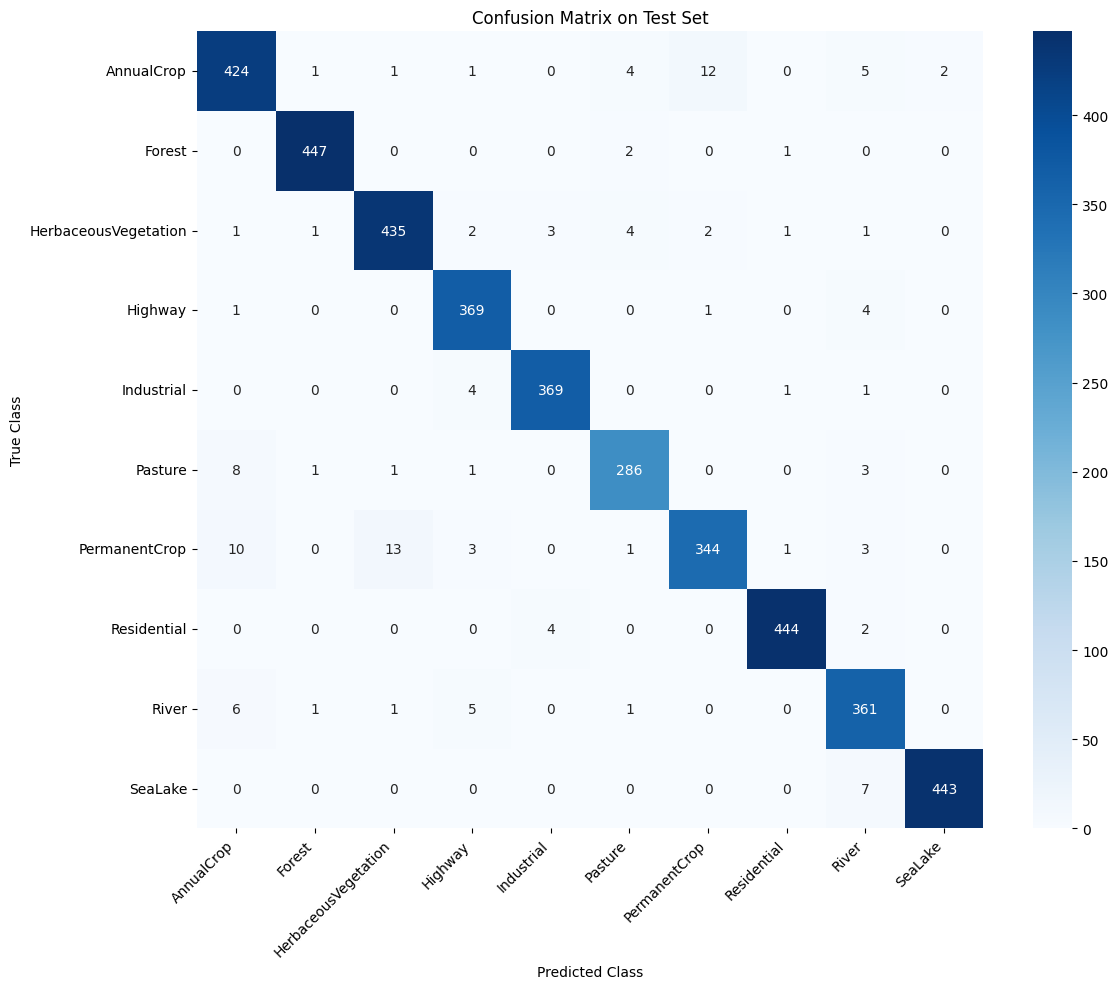

In [28]:
# ==============================================================================
# CELL PURPOSE: Generate and save the raw-count confusion matrix.
# ASSIGNMENT REQUIREMENT: Visualizations: generate a confusion matrix visualization.
# NOTE: Run the notebook cells in order so variables and outputs remain available.
# ==============================================================================
confusion_matrix_counts = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(
    confusion_matrix_counts,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.title('Confusion Matrix on Test Set')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(OUTPUT_ROOT / 'confusion_matrix_counts.png', dpi=200, bbox_inches='tight')
plt.show()

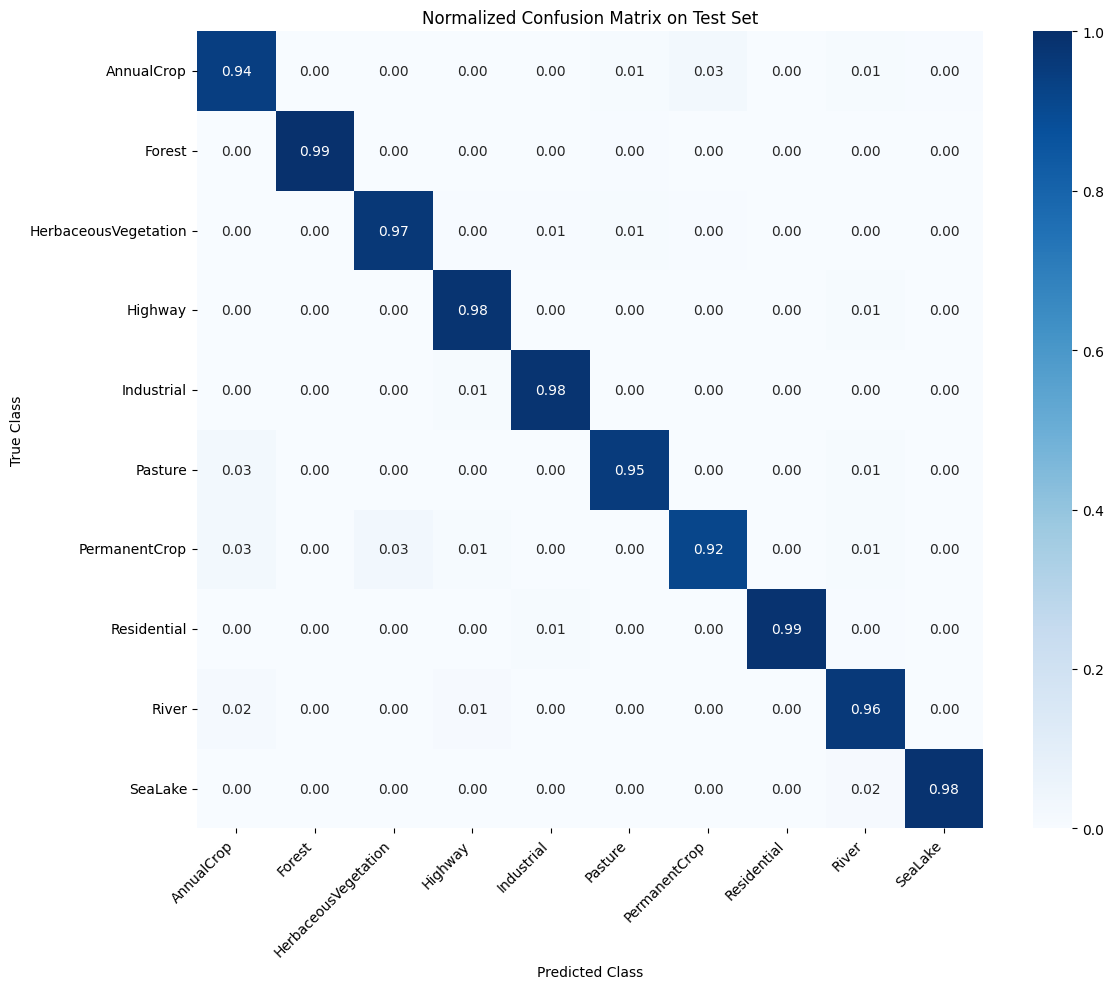

In [29]:
# ==============================================================================
# CELL PURPOSE: Generate and save the row-normalized confusion matrix for easier class-wise comparison.
# ASSIGNMENT REQUIREMENT: Visualizations and Per-Class Analysis: inspect relative prediction performance by class.
# NOTE: Run the notebook cells in order so variables and outputs remain available.
# ==============================================================================
confusion_matrix_normalized = confusion_matrix(
    y_true, y_pred, normalize='true'
)

plt.figure(figsize=(12, 10))
sns.heatmap(
    confusion_matrix_normalized,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
    vmin=0,
    vmax=1
)
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.title('Normalized Confusion Matrix on Test Set')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(OUTPUT_ROOT / 'confusion_matrix_normalized.png', dpi=200, bbox_inches='tight')
plt.show()

## 12. Per-Class Performance Analysis

The assignment asks for the best and worst performing classes. Per-class precision, recall, F1-score, support, and accuracy are calculated below.

In [30]:
# ==============================================================================
# CELL PURPOSE: Generate and save the raw-count confusion matrix.
# ASSIGNMENT REQUIREMENT: Visualizations: generate a confusion matrix visualization.
# NOTE: Run the notebook cells in order so variables and outputs remain available.
# ==============================================================================
per_class_precision, per_class_recall, per_class_f1, per_class_support = (
    precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=np.arange(num_classes),
        zero_division=0
    )
)

per_class_accuracy = confusion_matrix_counts.diagonal() / confusion_matrix_counts.sum(axis=1)

per_class_results = pd.DataFrame({
    'Class': class_names,
    'Precision': per_class_precision,
    'Recall': per_class_recall,
    'F1-score': per_class_f1,
    'Class Accuracy': per_class_accuracy,
    'Support': per_class_support.astype(int)
})

per_class_results = per_class_results.sort_values('F1-score', ascending=False).reset_index(drop=True)
display(per_class_results.style.format({
    'Precision': '{:.4f}',
    'Recall': '{:.4f}',
    'F1-score': '{:.4f}',
    'Class Accuracy': '{:.4f}'
}))

,Class,Precision,Recall,F1-score,Class Accuracy,Support
0,Forest,0.9911,0.9933,0.9922,0.9933,450
1,SeaLake,0.9955,0.9844,0.9899,0.9844,450
2,Residential,0.9911,0.9867,0.9889,0.9867,450
3,Industrial,0.9814,0.9840,0.9827,0.9840,375
4,Highway,0.9584,0.9840,0.9711,0.9840,375
5,HerbaceousVegetation,0.9645,0.9667,0.9656,0.9667,450
6,Pasture,0.9597,0.9533,0.9565,0.9533,300
7,River,0.9328,0.9627,0.9475,0.9627,375
8,AnnualCrop,0.9422,0.9422,0.9422,0.9422,450
9,PermanentCrop,0.9582,0.9173,0.9373,0.9173,375


In [31]:
# ==============================================================================
# CELL PURPOSE: Identify and report the best and worst performing classes using per-class F1-score.
# ASSIGNMENT REQUIREMENT: Model Evaluation: analyze the best and worst performing classes.
# NOTE: Run the notebook cells in order so variables and outputs remain available.
# ==============================================================================
best_class_row = per_class_results.iloc[0]
worst_class_row = per_class_results.iloc[-1]

print('Best performing class based on F1-score:')
print(
    f"  {best_class_row['Class']} | "
    f"Precision={best_class_row['Precision']:.4f}, "
    f"Recall={best_class_row['Recall']:.4f}, "
    f"F1={best_class_row['F1-score']:.4f}"
)

print('\nWorst performing class based on F1-score:')
print(
    f"  {worst_class_row['Class']} | "
    f"Precision={worst_class_row['Precision']:.4f}, "
    f"Recall={worst_class_row['Recall']:.4f}, "
    f"F1={worst_class_row['F1-score']:.4f}"
)

Best performing class based on F1-score:
  Forest | Precision=0.9911, Recall=0.9933, F1=0.9922

Worst performing class based on F1-score:
  PermanentCrop | Precision=0.9582, Recall=0.9173, F1=0.9373


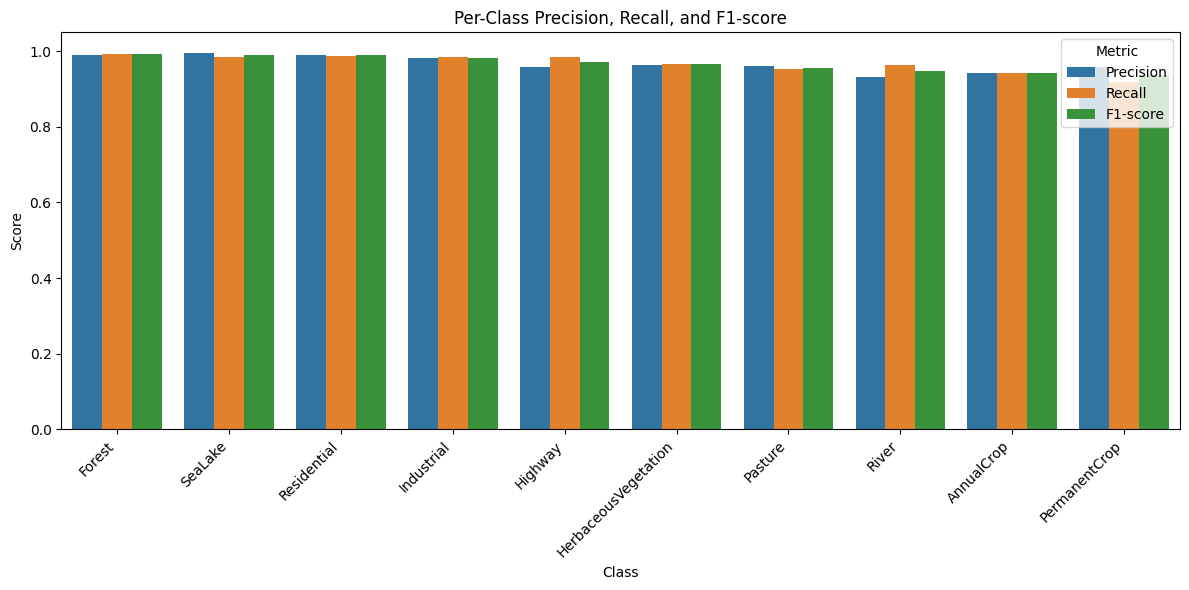

In [32]:
# ==============================================================================
# CELL PURPOSE: Plot class-wise precision, recall, and F1-score for visual comparison.
# ASSIGNMENT REQUIREMENT: Visualizations and Per-Class Analysis: compare class-level performance.
# NOTE: Run the notebook cells in order so variables and outputs remain available.
# ==============================================================================
plt.figure(figsize=(12, 6))
plot_data = per_class_results.melt(
    id_vars='Class',
    value_vars=['Precision', 'Recall', 'F1-score'],
    var_name='Metric',
    value_name='Score'
)
sns.barplot(data=plot_data, x='Class', y='Score', hue='Metric')
plt.ylim(0, 1.05)
plt.title('Per-Class Precision, Recall, and F1-score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(OUTPUT_ROOT / 'per_class_metrics.png', dpi=200, bbox_inches='tight')
plt.show()

### Most Frequent Class Confusions

The largest off-diagonal confusion-matrix values show which class pairs the model confuses most often.

In [33]:
# ==============================================================================
# CELL PURPOSE: Generate and save the raw-count confusion matrix.
# ASSIGNMENT REQUIREMENT: Visualizations: generate a confusion matrix visualization.
# NOTE: Run the notebook cells in order so variables and outputs remain available.
# ==============================================================================
confusion_records = []
for true_index in range(num_classes):
    for predicted_index in range(num_classes):
        if true_index != predicted_index:
            confusion_records.append({
                'True Class': class_names[true_index],
                'Predicted Class': class_names[predicted_index],
                'Count': int(confusion_matrix_counts[true_index, predicted_index])
            })

confusion_dataframe = pd.DataFrame(confusion_records)
confusion_dataframe = confusion_dataframe.sort_values('Count', ascending=False)
display(confusion_dataframe.head(10).reset_index(drop=True))

,True Class,Predicted Class,Count
0,PermanentCrop,HerbaceousVegetation,13
1,AnnualCrop,PermanentCrop,12
2,PermanentCrop,AnnualCrop,10
3,Pasture,AnnualCrop,8
4,SeaLake,River,7
5,River,AnnualCrop,6
6,River,Highway,5
7,AnnualCrop,River,5
8,AnnualCrop,Pasture,4
9,HerbaceousVegetation,Pasture,4


## 13. Visualize Sample Predictions

Correct predictions are shown in green and incorrect predictions in red after the cell is executed.

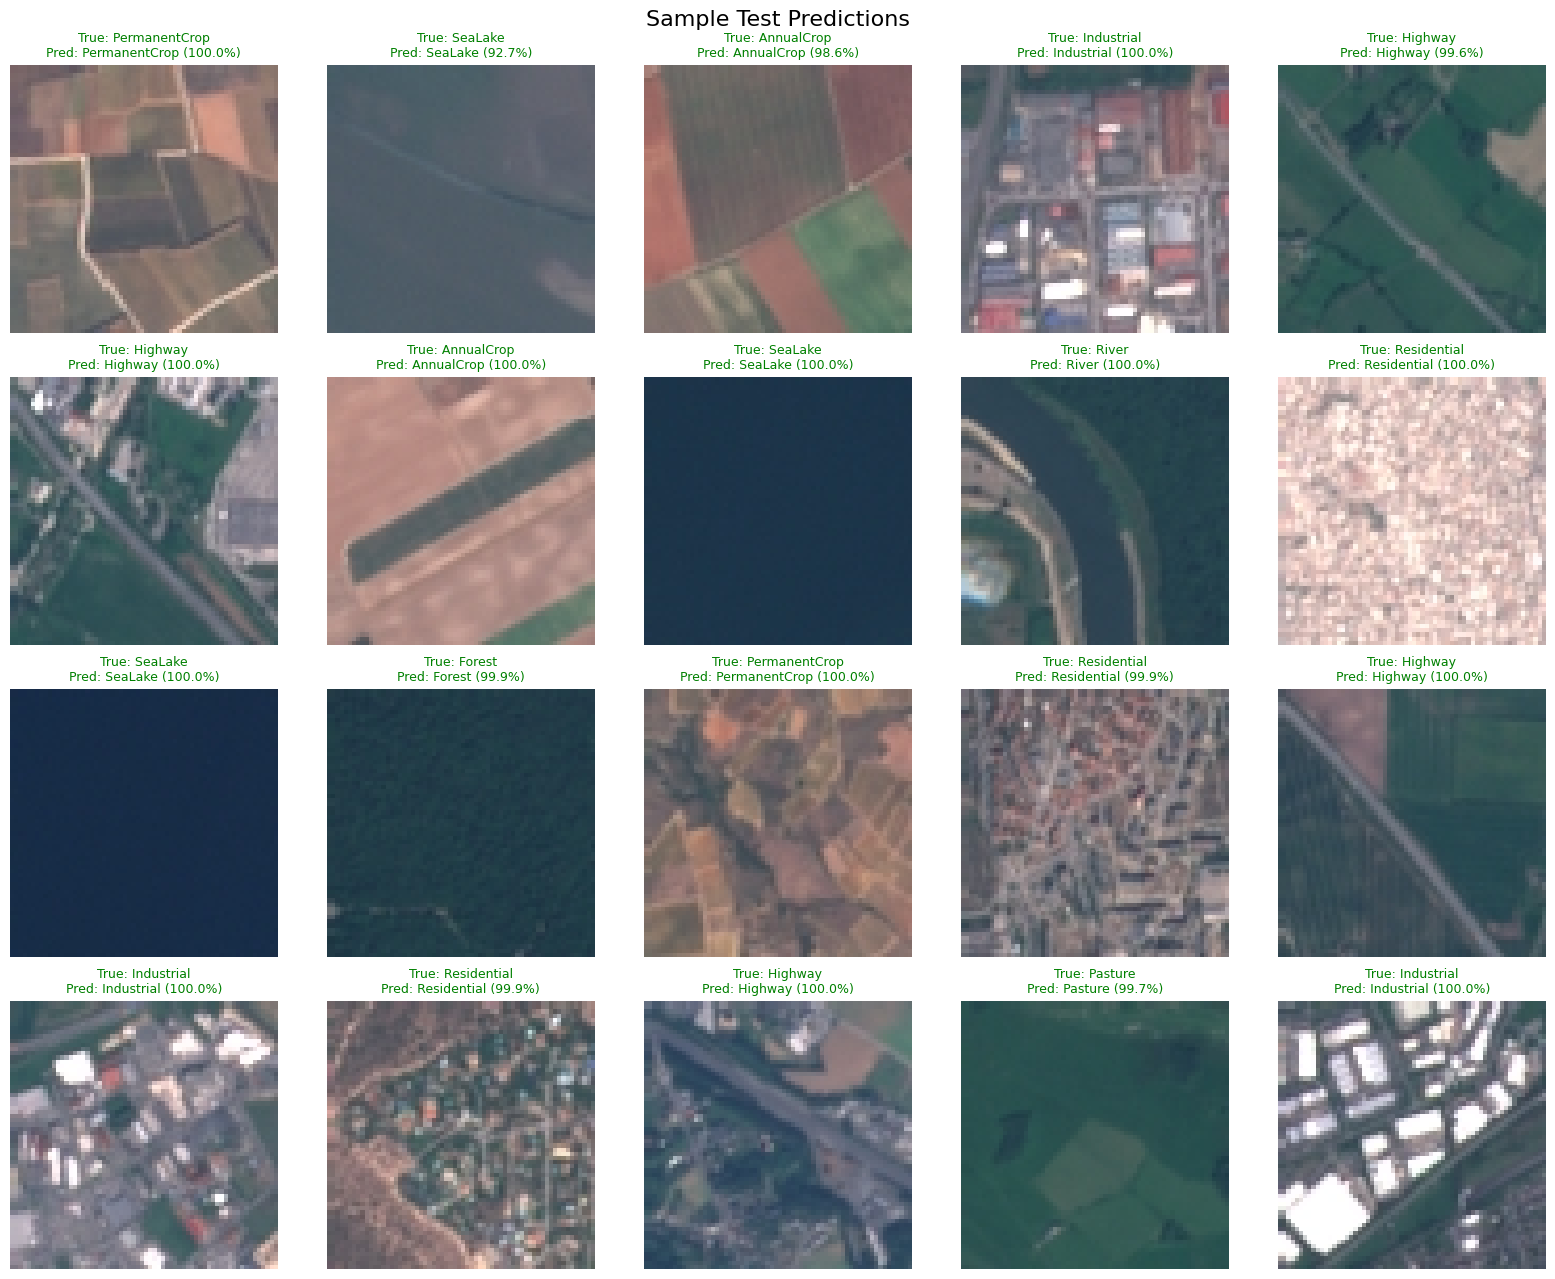

In [34]:
# ==============================================================================
# CELL PURPOSE: Display sample test predictions after reversing normalization for readable images.
# ASSIGNMENT REQUIREMENT: Analysis and Discussion: visually inspect correct and incorrect predictions.
# NOTE: Run the notebook cells in order so variables and outputs remain available.
# ==============================================================================
def denormalize_image(image_tensor):
    image = image_tensor.clone().cpu()
    mean_tensor = torch.tensor(mean).view(3, 1, 1)
    std_tensor = torch.tensor(std).view(3, 1, 1)
    image = image * std_tensor + mean_tensor
    return image.clamp(0, 1)


sample_images, sample_labels = next(iter(test_loader))
sample_images_device = sample_images.to(device)

with torch.no_grad():
    sample_outputs = best_model(sample_images_device)
    sample_probabilities = torch.softmax(sample_outputs, dim=1)
    sample_predictions = sample_probabilities.argmax(dim=1).cpu()
    sample_confidences = sample_probabilities.max(dim=1).values.cpu()

number_to_show = 20
fig, axes = plt.subplots(4, 5, figsize=(16, 13))

for index, axis in enumerate(axes.flatten()):
    image = denormalize_image(sample_images[index]).permute(1, 2, 0).numpy()
    true_label = sample_labels[index].item()
    predicted_label = sample_predictions[index].item()
    confidence = sample_confidences[index].item() * 100

    title_color = 'green' if true_label == predicted_label else 'red'
    axis.imshow(image)
    axis.set_title(
        f'True: {class_names[true_label]}\n'
        f'Pred: {class_names[predicted_label]} ({confidence:.1f}%)',
        color=title_color,
        fontsize=9
    )
    axis.axis('off')

plt.suptitle('Sample Test Predictions', fontsize=16)
plt.tight_layout()
plt.savefig(OUTPUT_ROOT / 'sample_predictions.png', dpi=200, bbox_inches='tight')
plt.show()

## 14. Analysis and Discussion of Results

After running all cells, replace the bracketed values below using the generated outputs.

### Training Behavior

The training and validation curves show how the model learned over the epochs. The best validation accuracy was **[insert value]%** at epoch **[insert epoch]**. A small gap between training and validation accuracy indicates good generalization, while a large gap would indicate overfitting.

### Test Performance

The independent test accuracy was **[insert value]%**. The macro F1-score was **[insert value]**, which gives equal importance to every class. The weighted F1-score was **[insert value]**, which considers class support.

### Best and Worst Classes

Based on F1-score, the best-performing class was **[insert class]**, and the lowest-performing class was **[insert class]**. The confusion matrix should be used to explain whether the weakest class is visually similar to another land-use category.

### Error Analysis

The most frequent confusion pairs printed above identify the main limitations of the model. For example, classes containing similar vegetation textures may be confused because a 64 × 64 RGB image contains limited contextual information.

### Regularization and Optimization

Data augmentation, batch normalization, dropout, and weight decay were used to reduce overfitting. Adam provided adaptive updates, while cosine annealing gradually lowered the learning rate throughout training.

## 15. Conclusion and Future Work

### Conclusion

A custom convolutional neural network was developed to classify EuroSAT RGB images into ten land-use classes. The complete workflow included dataset loading, preprocessing, augmentation, stratified splitting, custom model construction, Adam optimization, cross-entropy loss, validation monitoring, model checkpoint saving and loading, and comprehensive test evaluation.

### Future Work

Future improvements may include:

1. Increasing the number of training epochs with controlled early stopping.
2. Performing systematic hyperparameter tuning.
3. Comparing the custom CNN with transfer-learning models such as ResNet or EfficientNet.
4. Using higher-resolution satellite images.
5. Applying stronger augmentation or mixup.
6. Adding explainability methods such as Grad-CAM.

## 16. Export Results and Submission Checklist

The assignment requires the notebook and saved model weights. The following cell creates a compact result summary and lists the generated files.

In [35]:
# ==============================================================================
# CELL PURPOSE: Identify and report the best and worst performing classes using per-class F1-score.
# ASSIGNMENT REQUIREMENT: Model Evaluation: analyze the best and worst performing classes.
# NOTE: Run the notebook cells in order so variables and outputs remain available.
# ==============================================================================
result_summary = {
    'student_id': STUDENT_ID,
    'student_name': STUDENT_NAME,
    'dataset': 'EuroSAT RGB',
    'number_of_classes': num_classes,
    'training_images': len(train_dataset),
    'validation_images': len(validation_dataset),
    'test_images': len(test_dataset),
    'best_epoch': best_epoch,
    'best_validation_accuracy': float(best_validation_accuracy),
    'test_accuracy': float(test_accuracy),
    'macro_precision': float(macro_precision),
    'macro_recall': float(macro_recall),
    'macro_f1': float(macro_f1),
    'weighted_f1': float(weighted_f1),
    'best_class': str(best_class_row['Class']),
    'worst_class': str(worst_class_row['Class'])
}

with open(OUTPUT_ROOT / f'CNN_{STUDENT_ID}_result_summary.json', 'w') as file:
    json.dump(result_summary, file, indent=4)

print('Generated output files:')
for output_file in sorted(OUTPUT_ROOT.iterdir()):
    print(' -', output_file.name)

Generated output files:
 - CNN_22-49218-3_best.pth
 - CNN_22-49218-3_classification_report.csv
 - CNN_22-49218-3_final.pth
 - CNN_22-49218-3_full_model.pth
 - CNN_22-49218-3_history.csv
 - CNN_22-49218-3_result_summary.json
 - accuracy_curves.png
 - confusion_matrix_counts.png
 - confusion_matrix_normalized.png
 - loss_curves.png
 - per_class_metrics.png
 - sample_predictions.png


### Download All Saved `.pth` Model Files

This cell confirms that the best checkpoint, final weights, and complete trained model were saved. It then creates one ZIP archive for convenient Colab download.


In [36]:
# ==============================================================================
# CELL PURPOSE: Set student information, hyperparameters, output paths, random seeds, and the available computation device.
# ASSIGNMENT REQUIREMENT: Training and Optimization: state hyperparameters and provide a rationale in the surrounding markdown.
# NOTE: Run the notebook cells in order so variables and outputs remain available.
# ==============================================================================
from zipfile import ZipFile

model_files = [BEST_MODEL_PATH, FINAL_MODEL_PATH, FULL_MODEL_PATH]
missing_files = [str(path) for path in model_files if not path.exists()]

if missing_files:
    raise FileNotFoundError(
        'Run the training and model-saving cells first. Missing files: ' + ', '.join(missing_files)
    )

MODEL_PACKAGE_PATH = OUTPUT_ROOT / f'CNN_{STUDENT_ID}_trained_models.zip'
with ZipFile(MODEL_PACKAGE_PATH, 'w') as zip_file:
    for model_path in model_files:
        zip_file.write(model_path, arcname=model_path.name)

print('Saved trained model files:')
for model_path in model_files:
    print(f' - {model_path.name}: {model_path.stat().st_size / (1024 ** 2):.2f} MB')
print('Model package created at:', MODEL_PACKAGE_PATH)

# Optional Colab download: remove the # symbols from the next two lines when needed.
# from google.colab import files
# files.download(str(MODEL_PACKAGE_PATH))


Saved trained model files:
 - CNN_22-49218-3_best.pth: 7.12 MB
 - CNN_22-49218-3_final.pth: 2.38 MB
 - CNN_22-49218-3_full_model.pth: 2.39 MB
Model package created at: /content/cnn_assignment_outputs/CNN_22-49218-3_trained_models.zip
